[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch04-simple_workbook.ipynb)

# `cat`, `mat` and `dog`

A computer compares two words by the cosine of their vectors. Is `mat` or
`dog` closer to `cat`? The answer depends on what each vector counts.

In [1]:
#@title Setup: run this cell first
import os
import re
import urllib.request
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


# The lecture's three sentences, and its stylised vectors of cat (centre) and sat (context).
SENTENCES = ["the cat sat on the mat", "the dog sat on the rug", "the cat chased the dog"]
V_CAT, U_SAT = np.array([0.6, 0.4, -0.2, 0.2]), np.array([1.0, 0.8, -0.5, 0.4])
# A word of the novel needs 5 uses for a vector of 100 numbers. FastText's pieces run from 3 to 6
# characters: Bojanowski et al. 2017, section 3.2.
MIN_COUNT, DIM, LENGTHS = 5, 100, (3, 6)
plt.rcParams.update({"xtick.labelsize": 8, "ytick.labelsize": 8})


class Refused(Exception):  # a setting a cell refuses: Colab prints the one sentence, without the stack
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def bars(title, labels, values, xlabel, focus=None, fmt="%.3f"):  # one chart of labelled bars
    fig, ax = plt.subplots(figsize=(6, 0.45 * len(values) + 1.2), layout="constrained")
    b = ax.barh(range(len(values)), values, tick_label=labels, color=["C3" if x == focus else "C0" for x in labels])
    ax.bar_label(b, fmt=fmt, padding=2, fontsize=8)
    ax.set(title=title, xlabel=xlabel, xlim=(0, 1.3 * (max(values) or 1)), ylim=(len(values) - 0.5, -0.5))
    plt.show()


def cosine(a, b):  # the dot product of two vectors held as Counters, over their two lengths
    return sum(a[k] * b[k] for k in a) / np.sqrt(sum(x * x for x in a.values()) * sum(x * x for x in b.values()))


# Step 1: each word's row counts the words one position before and after each of its uses.
ROWS = {}
for t in (s.split() for s in SENTENCES):
    for i, w in enumerate(t):
        ROWS.setdefault(w, Counter()).update(t[max(i - 1, 0):i] + t[i + 1:i + 2])


def compare(word):
    w = word.strip().lower() if isinstance(word, str) else word
    if w not in ROWS or w == "cat":
        raise Refused(f"WORD is {word!r}: WORD takes one of {', '.join(x for x in ROWS if x != 'cat')}.")
    for x in ("cat", w):
        print(f"row of {x}: " + ", ".join(f"{c} {m}" for c, m in ROWS[x].items()))
    print(f"cosine of cat and {w}: {cosine(Counter(['cat']), Counter([w])):g} as one-hot vectors, "
          f"{cosine(ROWS['cat'], ROWS[w]):.3f} as neighbour rows")
    others = sorted((x for x in ROWS if x != "cat"), key=lambda x: -cosine(ROWS["cat"], ROWS[x]))
    bars("neighbour rows", others, [cosine(ROWS["cat"], ROWS[x]) for x in others], "cosine with cat", focus=w)


# Step 2: one step for the real pair cat, sat adds ETA × (1 − σ(score)) × u_sat to v_cat.
def sigma(z):
    return 1 / (1 + np.exp(-z))


def scores(eta):
    if type(eta) not in (int, float) or not 0 <= eta <= 10:
        raise Refused(f"ETA is {eta!r}: ETA takes a number from 0 to 10.")
    new = V_CAT + eta * (1 - sigma(V_CAT @ U_SAT)) * U_SAT
    return V_CAT @ U_SAT, new @ U_SAT, new


def step(eta):
    s, s2, new = scores(eta)
    print("v_cat before: (" + ", ".join(f"{x:.3f}" for x in V_CAT) + "), after: (" + ", ".join(f"{x:.3f}" for x in new) + ")")
    print(f"score of cat and sat: {s:.3f} before, {s2:.3f} after; σ(score): {sigma(s):.3f} before, {sigma(s2):.3f} after")
    bars("one training step", ["before", "after"], [s, s2], "score of cat and sat")


# Step 3: each word of the novel used at least MIN_COUNT times gets a row counting its neighbours one
# position away; each count is weighted by how far it exceeds chance (positive PMI), and truncated SVD
# compresses the weighted rows to DIM numbers per word.
tokens = [w for chapter in load_novel() for w in chapter]
counts = Counter(tokens)
vocab = [w for w, c in counts.most_common() if c >= MIN_COUNT]
index, n = {w: i for i, w in enumerate(vocab)}, len(vocab)
ids = np.array([index.get(w, -1) for w in tokens])
both = (ids[:-1] >= 0) & (ids[1:] >= 0)
M = np.bincount(ids[:-1][both] * n + ids[1:][both], minlength=n * n).reshape(n, n)
M = M + M.T
ppmi = np.maximum(np.log(np.where(M > 0, M * M.sum() / np.maximum(np.outer(M.sum(1), M.sum(1)), 1), 1)), 0)
U, S, _ = np.linalg.svd(ppmi, hermitian=True)
dense = U[:, :DIM] * S[:DIM]


def closest(w, k=5):  # the k words whose vectors have the largest cosine with the vector of w
    c = dense @ dense[index[w]] / np.maximum(np.linalg.norm(dense, axis=1) * np.linalg.norm(dense[index[w]]), 1e-12)
    return [(vocab[j], c[j]) for j in np.argsort(-c, kind="stable") if j != index[w]][:k]


def nearest(word):
    w = word.strip().lower() if isinstance(word, str) else word
    if w not in index:
        raise Refused(f"WORD is {word!r}: WORD takes a word used at least {MIN_COUNT} times in the novel, such as darcy.")
    near = closest(w)
    bars(f"{w}: {counts[w]:,} uses", [v for v, _ in near], [c for _, c in near], "cosine with its vector")


def pieces(word):  # FastText's character n-grams of the word inside its markers < and >
    if not (isinstance(word, str) and word.strip().isalpha() and len(word.strip()) <= 30):
        raise Refused(f"FASTTEXT_WORD is {word!r}: FASTTEXT_WORD takes a word of 1 to 30 letters.")
    w = "<" + word.strip().lower() + ">"
    return [w[i:i + k] for k in range(LENGTHS[0], LENGTHS[1] + 1) for i in range(len(w) - k + 1)]


display(Markdown(f"The three sentences: {len(' '.join(SENTENCES).split())} tokens of {len(ROWS)} words. "
                 f"The novel: {len(tokens):,} tokens, {n:,} words used at least {MIN_COUNT} times."))

The three sentences: 17 tokens of 8 words. The novel: 122,174 tokens, 2,077 words used at least 5 times.

## 1. Counting neighbours

A one-hot vector gives each word its own axis. A neighbour row counts the
words beside each use of a word in the lecture's three sentences. Run the
cell: how close is `dog` to `cat` each way? Then set `WORD` to `mat` and to
`rug`, and run it again.

row of cat: the 2, sat 1, chased 1
row of dog: the 2, sat 1
cosine of cat and dog: 0 as one-hot vectors, 0.913 as neighbour rows


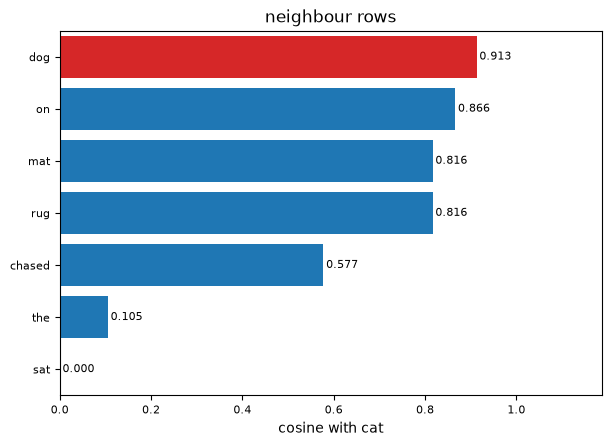

In [2]:
WORD = "dog"
compare(WORD)

### Solution

In [3]:
w = WORD.strip().lower()
cd, cm = cosine(ROWS["cat"], ROWS["dog"]), cosine(ROWS["cat"], ROWS["mat"])
display(Markdown(f"As one-hot vectors `cat` and `{w}` have cosine 0, as every pair of different words does; as neighbour "
                 f"rows they have {cosine(ROWS['cat'], ROWS[w]):.3f}. Counted by company, `dog` is closer to `cat` than `mat` is, "
                 f"{cd:.3f} against {cm:.3f}, and `on` reaches {cosine(ROWS['cat'], ROWS['on']):.3f} because it too stands "
                 "beside `the` and `sat`."))

As one-hot vectors `cat` and `dog` have cosine 0, as every pair of different words does; as neighbour rows they have 0.913. Counted by company, `dog` is closer to `cat` than `mat` is, 0.913 against 0.816, and `on` reaches 0.866 because it too stands beside `the` and `sat`.

## 2. One training step

Skip-gram scores the pair `cat`, `sat` by the dot product of the vector of
`cat` and the vector of `sat`, and σ of the score is the model's chance that
the pair is real. One training step moves the vector of `cat` toward the
vector of `sat`, by the learning rate `ETA` times the error. Run the cell,
then set `ETA` to 1 and to 2: how far does the score rise each time?

v_cat before: (0.600, 0.400, -0.200, 0.200), after: (0.700, 0.480, -0.250, 0.240)
score of cat and sat: 1.100 before, 1.305 after; σ(score): 0.750 before, 0.787 after


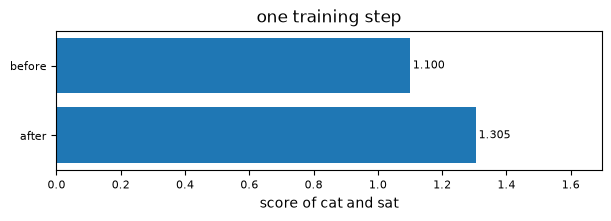

In [4]:
ETA = 0.4
step(ETA)

### Solution

In [5]:
s, s2, _ = scores(ETA)
rise = {e: scores(e)[1] - scores(e)[0] for e in (0.4, 1, 2)}
display(Markdown(f"At learning rate {ETA:g} the score rises from {s:.3f} to {s2:.3f}, and σ from {sigma(s):.3f} to {sigma(s2):.3f}. "
                 f"The rise is proportional to the learning rate: {rise[0.4]:.3f} at 0.4, {rise[1]:.3f} at 1 and {rise[2]:.3f} at 2."))

At learning rate 0.4 the score rises from 1.100 to 1.305, and σ from 0.750 to 0.787. The rise is proportional to the learning rate: 0.205 at 0.4, 0.512 at 1 and 1.024 at 2.

## 3. Nearest words in Pride and Prejudice

The setup counted the neighbours of every word used at least 5 times in the
novel and compressed each word's row of counts to a vector of 100 numbers.
Run the cell to see the five words whose vectors are closest to the vector of
`darcy`. Then try `father`, `walked` and `the`: what do the nearest words of
each have in common?

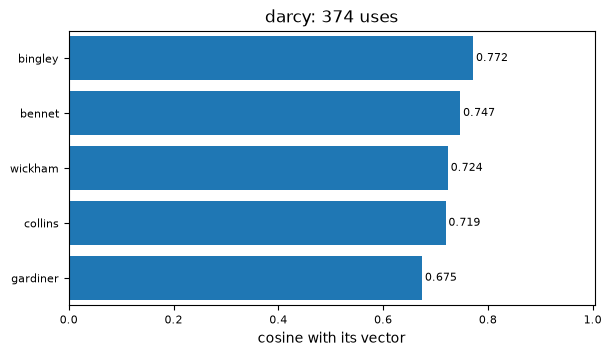

In [6]:
WORD = "darcy"
nearest(WORD)

### Solution

In [7]:
lists = "; ".join(f"`{x}`: " + ", ".join(f"`{v}` {c:.3f}" for v, c in closest(x, 3))
                  for x in dict.fromkeys([WORD.strip().lower(), "darcy", "father", "walked", "the"]))
top = {x: closest(x, 1)[0][1] for x in ("darcy", "father", "walked", "the")}
display(Markdown(f"The three nearest words: {lists}. `darcy` stands beside other surnames, `father` beside other kin and "
                 f"`walked` beside other verbs, while `the`, the commonest word, has the lowest top cosine, {top['the']:.3f} "
                 f"against {min(top['darcy'], top['father'], top['walked']):.3f} or more, since it stands beside every kind of word."))

The three nearest words: `darcy`: `bingley` 0.772, `bennet` 0.747, `wickham` 0.724; `father`: `mother` 0.772, `parents` 0.714, `uncle` 0.686; `walked`: `comes` 0.751, `came` 0.741, `turned` 0.740; `the`: `of` 0.665, `and` 0.461, `whole` 0.430. `darcy` stands beside other surnames, `father` beside other kin and `walked` beside other verbs, while `the`, the commonest word, has the lowest top cosine, 0.665 against 0.751 or more, since it stands beside every kind of word.

## Appendix. FastText pieces

The cosine of two vectors a and b is their dot product over their two
lengths:

cos(a, b) = a · b / (‖a‖ ‖b‖),

1 for the same direction and 0 at a right angle. The novel's vectors come
from its neighbour rows: each count is weighted by how far it exceeds chance,
and the weighted rows are compressed to 100 numbers per word.

FastText builds a word's vector from pieces. It marks the word's edges with
< and > and cuts it into pieces of 3 to 6 characters. A word of L letters has
L + 2 characters with its markers, so it gives L + 3 − n pieces of length n,
or none when that is below 1.
The chart counts the pieces of `where`.

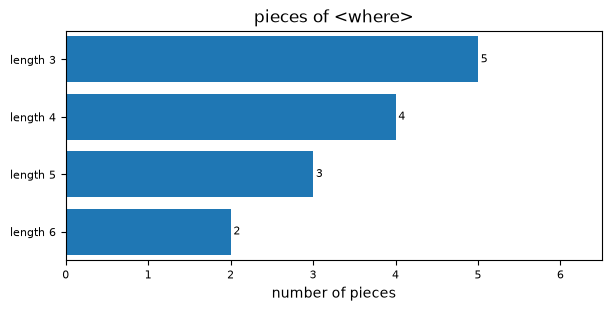

In [8]:
grams = pieces("where")
bars("pieces of <where>", [f"length {k}" for k in range(LENGTHS[0], LENGTHS[1] + 1)],
     [sum(len(g) == k for g in grams) for k in range(LENGTHS[0], LENGTHS[1] + 1)], "number of pieces", fmt="%d")

**Exercise.** Set `FASTTEXT_WORD` to `kittens`, then to a word of your own,
and rerun the cell. How many pieces does FastText cut from each word, and how
many vectors does it sum when the word has a vector of its own?

In [9]:
FASTTEXT_WORD = "cat"

grams = pieces(FASTTEXT_WORD)
for k in range(LENGTHS[0], LENGTHS[1] + 1):
    print(f"length {k}: " + ("  ".join(g for g in grams if len(g) == k) or "none"))
print(f"{len(grams)} pieces; {len(grams) + 1} vectors to sum with the word's own")

length 3: <ca  cat  at>
length 4: <cat  cat>
length 5: <cat>
length 6: none
6 pieces; 7 vectors to sum with the word's own


### Solution

In [10]:
found = "; ".join(f"`{x}` {len(pieces(x))} pieces, {len(pieces(x)) + 1} vectors with its own"
                  for x in dict.fromkeys(["where", "cat", "kittens", FASTTEXT_WORD.strip().lower()]))
display(Markdown(f"{found}. A word never seen in training has no vector of its own, and FastText sums its pieces alone."))

`where` 14 pieces, 15 vectors with its own; `cat` 6 pieces, 7 vectors with its own; `kittens` 22 pieces, 23 vectors with its own. A word never seen in training has no vector of its own, and FastText sums its pieces alone.